In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

C:\Users\mjaye\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\mjaye\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\mjaye\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations i

In [6]:
data = pd.read_csv("final_dataset.csv")
data = data[~(data['pathology.lymph_nodes_positive_ratio'] == np.inf)]
target = "diagnosis.residual_disease"

X = data.drop(columns=[target])
y = data[target]
le = LabelEncoder()
y = le.fit_transform(y)   # R0=0, Rx=1

X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
num_classes = len(np.unique(y))

In [7]:
models_with_smote = {
    "Logistic Regression": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=500, random_state=42))
    ]),
    
    "Random Forest": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    
    "Gradient Boosting": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),
    
    "XGBoost": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42))
    ]),
    
    "LightGBM": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', LGBMClassifier(random_state=42, verbose=-1))
    ])
}

# Train and evaluate models with SMOTE
results = []
roc_curves = {}

for name, pipeline in models_with_smote.items():
    print(f"Training {name}...")
    
    # Fit the pipeline (SMOTE + model)
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Get probabilities for binary classification
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)
        if y_prob.shape[1] == 2:  # Binary classification
            y_prob = y_prob[:, 1]
        else:
            y_prob = None
    else:
        y_prob = None
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Calculate AUC for binary classification
    auc = None
    if y_prob is not None and len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_curves[name] = (fpr, tpr, auc)
    
    results.append({
        "Model": name, 
        "Accuracy": acc, 
        "Precision": prec, 
        "Recall": rec, 
        "F1-score": f1, 
        "AUC": auc
    })
    
    print(f"{name} - Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

# Convert results to DataFrame for better visualization
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Final Results ===")
print(results_df.round(4))


Training Logistic Regression...
Logistic Regression - Accuracy: 0.8281, F1: 0.8324, AUC: 0.8661
Training Random Forest...
Random Forest - Accuracy: 0.9688, F1: 0.9688, AUC: 0.9665
Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.9688, F1: 0.9688, AUC: 0.9754
Training XGBoost...
XGBoost - Accuracy: 0.9844, F1: 0.9839, AUC: 0.9844
Training LightGBM...
LightGBM - Accuracy: 0.9375, F1: 0.9336, AUC: 0.9464

=== Final Results ===
                 Model  Accuracy  Precision  Recall  F1-score     AUC
0  Logistic Regression    0.8281     0.8371  0.8281    0.8324  0.8661
1        Random Forest    0.9688     0.9688  0.9688    0.9688  0.9665
2    Gradient Boosting    0.9688     0.9688  0.9688    0.9688  0.9754
3              XGBoost    0.9844     0.9846  0.9844    0.9839  0.9844
4             LightGBM    0.9375     0.9339  0.9375    0.9336  0.9464


C:\Users\mjaye\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:22:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
mlp = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid") if num_classes == 2 else Dense(num_classes, activation="softmax")
])

mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy" if num_classes == 2 else "categorical_crossentropy",
    metrics=["accuracy"]
)

# Convert labels for multi-class
y_train_mlp = y_train if num_classes == 2 else tf.keras.utils.to_categorical(y_train)
y_test_mlp = y_test if num_classes == 2 else tf.keras.utils.to_categorical(y_test)

mlp.fit(X_train_scaled, y_train_mlp, validation_split=0.2, epochs=30, batch_size=32, verbose=0)

mlp_pred = mlp.predict(X_test_scaled)

if num_classes == 2:
    mlp_pred_classes = (mlp_pred > 0.5).astype("int32")
    auc = roc_auc_score(y_test, mlp_pred)
else:
    mlp_pred_classes = np.argmax(mlp_pred, axis=1)
    auc = None

acc = accuracy_score(y_test, mlp_pred_classes)
prec = precision_score(y_test, mlp_pred_classes, average="weighted")
rec = recall_score(y_test, mlp_pred_classes, average="weighted")
f1 = f1_score(y_test, mlp_pred_classes, average="weighted")

results.append({"Model": "MLP", "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "AUC": auc})
results_df = pd.DataFrame(results)
print("\n=== Model Comparison Results ===")
print(results_df)

C:\Users\mjaye\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== Model Comparison Results ===
                 Model  Accuracy  Precision    Recall  F1-score       AUC
0  Logistic Regression  0.828125   0.837121  0.828125  0.832406  0.866071
1        Random Forest  0.968750   0.968750  0.968750  0.968750  0.966518
2    Gradient Boosting  0.968750   0.968750  0.968750  0.968750  0.975446
3              XGBoost  0.984375   0.984649  0.984375  0.983923  0.984375
4             LightGBM  0.937500   0.933908  0.937500  0.933584  0.946429
5                  MLP  0.921875   0.928279  0.921875  0.905789  0.854911


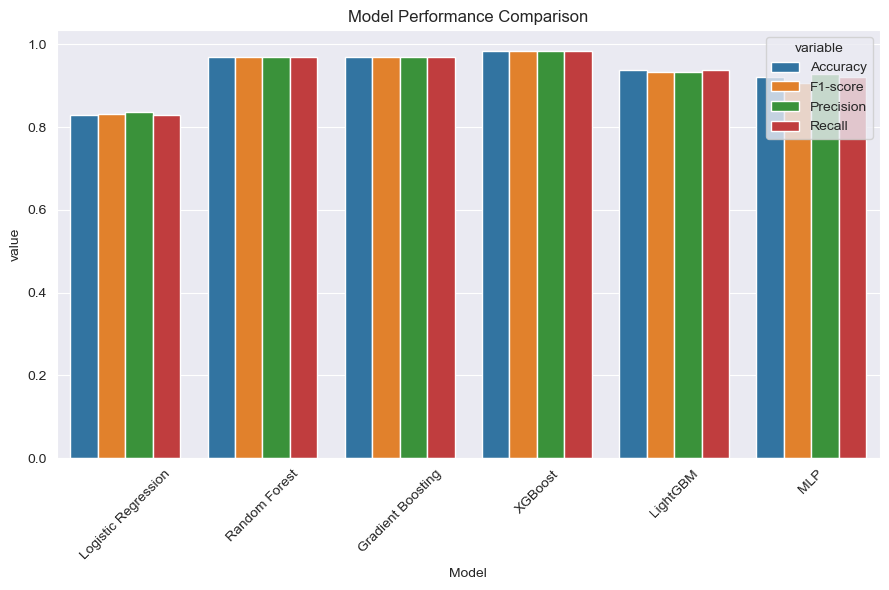

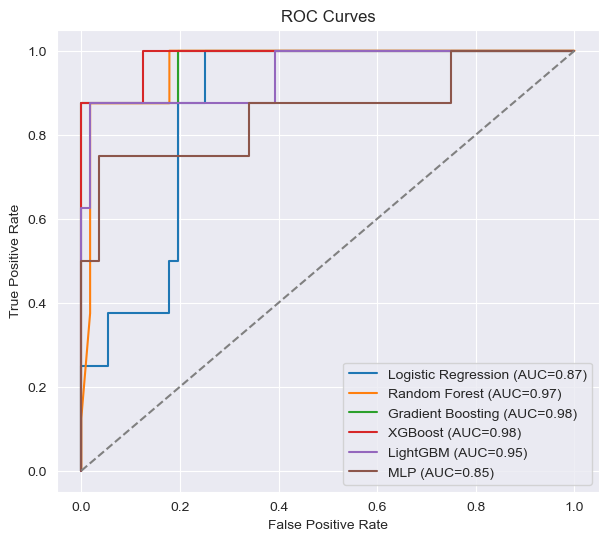

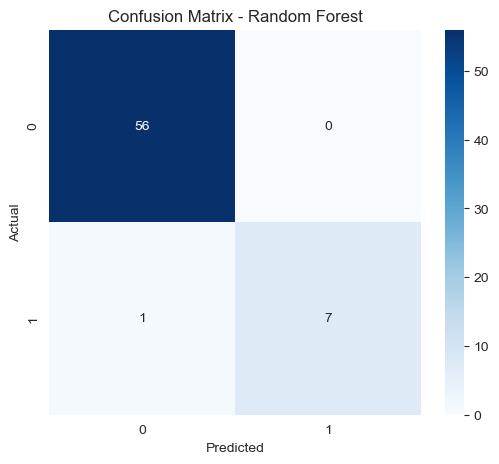

In [11]:
# --- Bar Plot ---
plt.figure(figsize=(9,6))
sns.barplot(data=results_df.melt(id_vars="Model", value_vars=["Accuracy","F1-score","Precision","Recall"]),
            x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- ROC Curves ---
if num_classes == 2:
    plt.figure(figsize=(7,6))
    for name, (fpr, tpr, auc) in roc_curves.items():
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    fpr, tpr, _ = roc_curve(y_test, mlp_pred)
    plt.plot(fpr, tpr, label=f"MLP (AUC={roc_auc_score(y_test, mlp_pred):.2f})")
    plt.plot([0,1],[0,1],"--", color="gray")
    plt.title("ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# --- Confusion Matrix (RF Example) ---
cm = confusion_matrix(y_test, models_with_smote["XGBoost"].predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
# --- SHAP Interpretability (RF Example) ---
explainer = shap.TreeExplainer(models_with_smote["Random Forest"])
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

InvalidModelError: Model type not yet supported by TreeExplainer: <class 'imblearn.pipeline.Pipeline'>